In [84]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, validation_curve, learning_curve, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## 1) Load Data

In [85]:
df = pd.read_csv("nigerian_loan_default.csv")
print(df.shape)
df.head()

(600, 11)


,age,monthly_income_ngn,loan_amount_ngn,tenure_months,interest_rate,prior_defaults,credit_score,has_bank_account,state,employment_type,defaulted
0,25,585352,1458642,24,21.22,2,710,1,Kaduna,Self-Employed,1
1,55,718777,2955061,24,27.89,0,489,1,Kaduna,Public,0
2,50,686015,2296226,12,25.05,2,371,1,Kaduna,Informal,1
3,40,190332,1970105,6,8.64,3,463,1,Kano,Public,0
4,40,757365,2714817,6,9.19,0,743,0,Abuja,Informal,1


In [102]:
TARGET = "defaulted"

numeric_features = [
    "age",
    "monthly_income_ngn",
    "loan_amount_ngn",
    "tenure_months",
    "interest_rate",
    "prior_defaults",
    "credit_score",
    "has_bank_account",
]

categorical_features = ["state", "employment_type"]

X = df[numeric_features + categorical_features]
y = df[TARGET]

print(y.value_counts(normalize=True).rename("rate"))

defaulted
0    0.59
1    0.41
Name: rate, dtype: float64


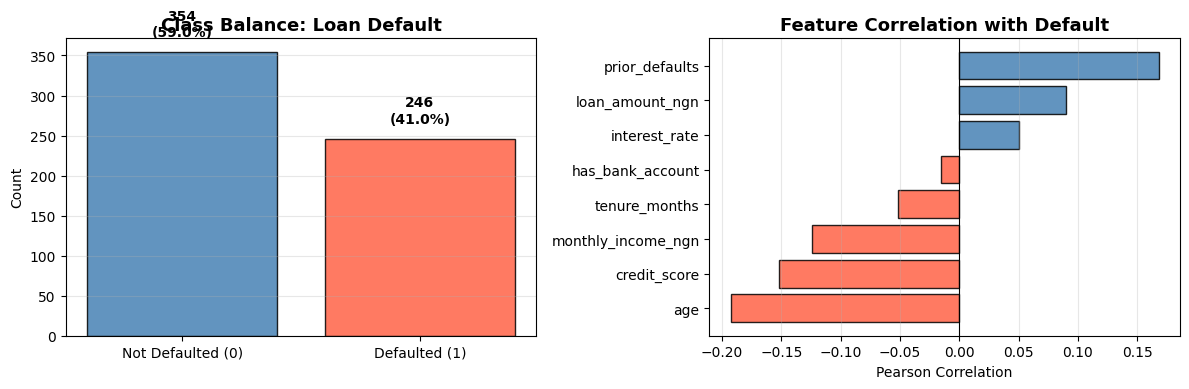

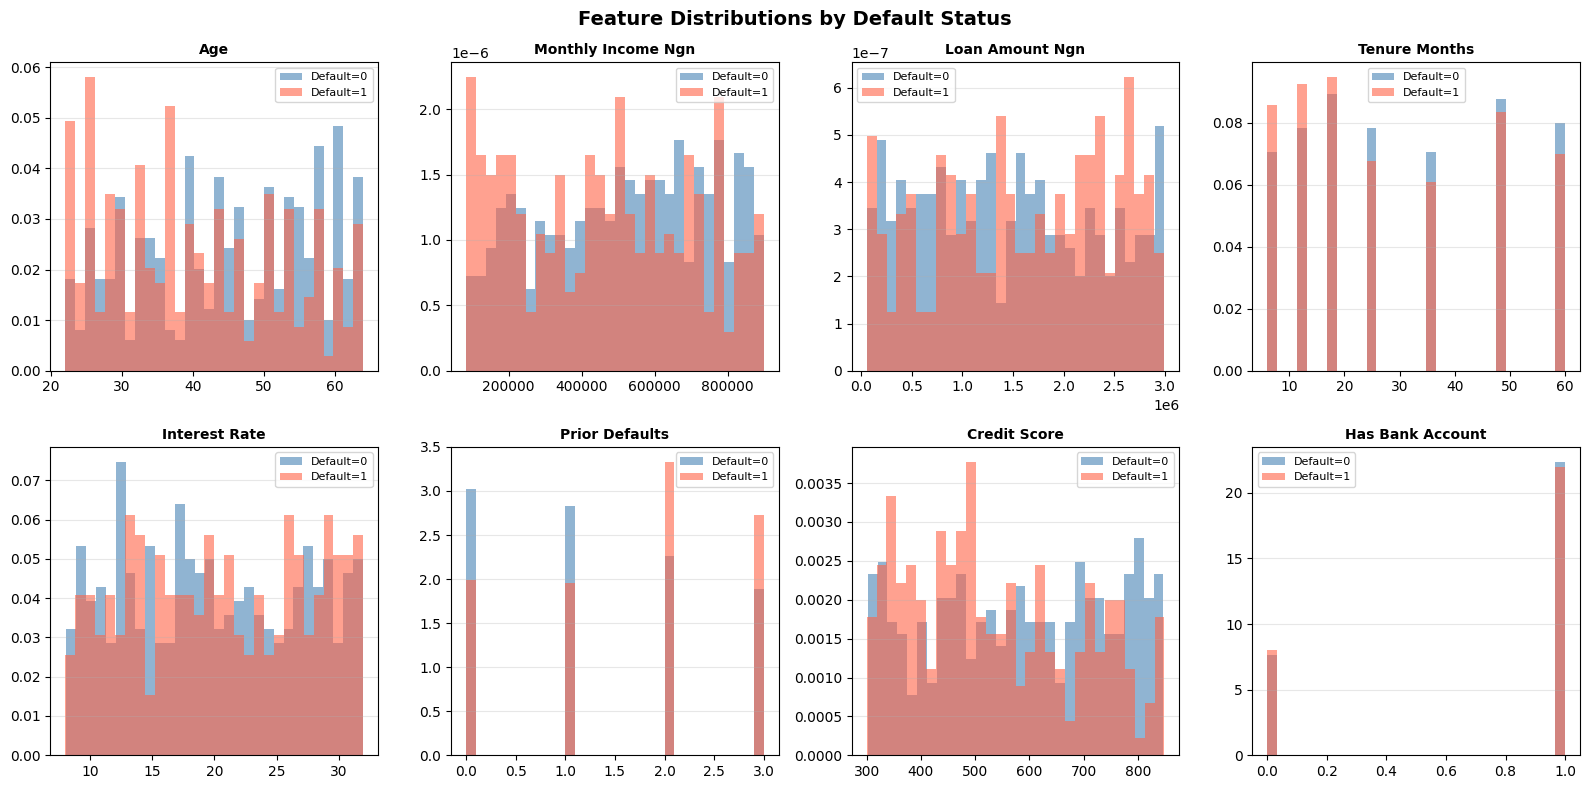

In [87]:
# --- EDA: Class Balance ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance bar chart
counts = y.value_counts()
axes[0].bar(['Not Defaulted (0)', 'Defaulted (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', alpha=0.85)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f'{v}\n({v/len(y)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Class Balance: Loan Default', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')

# Feature correlations with target (numeric only)
correlations = df[numeric_features + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
colors = ['tomato' if c < 0 else 'steelblue' for c in correlations]
axes[1].barh(correlations.index, correlations.values, color=colors, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Default', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# --- Feature distributions by class ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    ax = axes[idx]
    for label, color in zip([0, 1], ['steelblue', 'tomato']):
        ax.hist(df[df[TARGET] == label][feature], bins=30, alpha=0.6,
                color=color, label=f'Default={label}', edgecolor='none', density=True)
    ax.set_title(feature.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Feature Distributions by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2) Preprocessing Pipeline
We’ll one-hot encode categorical features and scale numeric features.

In [88]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
    ]
)

## 3) Validation Curve: Decision Tree Depth
- Small depth → underfitting (high bias)
- Large depth → overfitting (high variance)

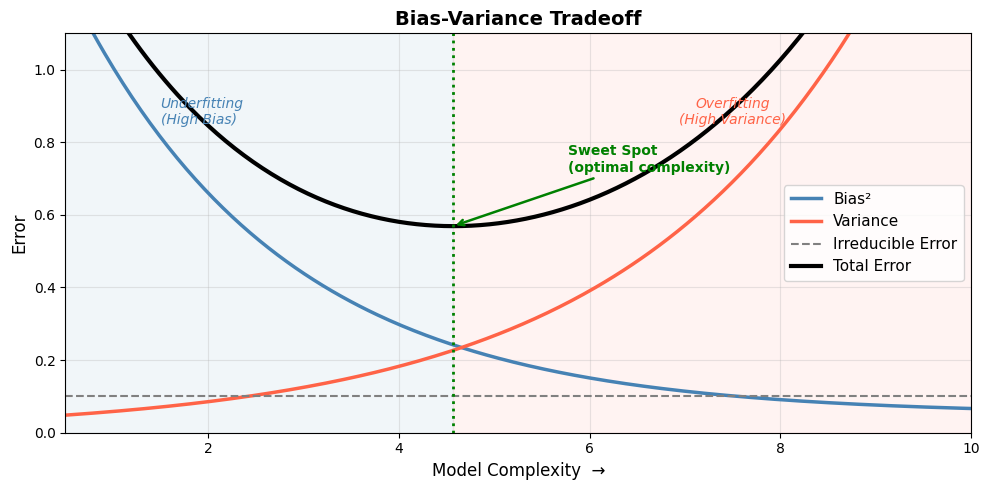

In [89]:
# --- Conceptual Bias-Variance Tradeoff Curve ---
complexity = np.linspace(0.5, 10, 300)

bias_sq  = 1.5 * np.exp(-0.45 * complexity) + 0.05
variance = 0.04 * np.exp(0.38 * complexity)
irreducible = np.full_like(complexity, 0.10)
total_error = bias_sq + variance + irreducible

best_idx = np.argmin(total_error)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(complexity, bias_sq,    lw=2.5, color='steelblue',  label='Bias²')
ax.plot(complexity, variance,   lw=2.5, color='tomato',     label='Variance')
ax.plot(complexity, irreducible,lw=1.5, color='gray',       linestyle='--', label='Irreducible Error')
ax.plot(complexity, total_error,lw=3,   color='black',      label='Total Error')

ax.axvline(complexity[best_idx], color='green', linestyle=':', lw=2)
ax.annotate('Sweet Spot\n(optimal complexity)',
            xy=(complexity[best_idx], total_error[best_idx]),
            xytext=(complexity[best_idx] + 1.2, total_error[best_idx] + 0.15),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.8),
            fontsize=10, color='green', fontweight='bold')

# Zone shading
ax.axvspan(0.5, complexity[best_idx], alpha=0.07, color='steelblue')
ax.axvspan(complexity[best_idx], 10,  alpha=0.07, color='tomato')
ax.text(1.5, 0.85, 'Underfitting\n(High Bias)', color='steelblue', fontsize=10, fontstyle='italic')
ax.text(7.5, 0.85, 'Overfitting\n(High Variance)', color='tomato', fontsize=10, fontstyle='italic', ha='center')

ax.set_xlabel('Model Complexity  →', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Bias-Variance Tradeoff', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_xlim(0.5, 10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

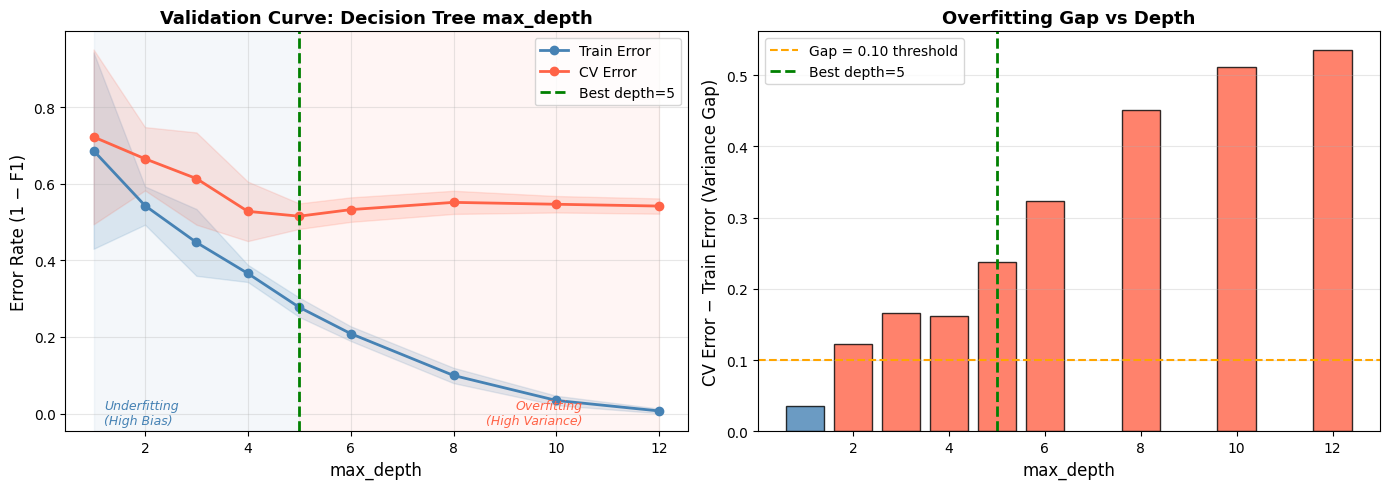

Best max_depth by CV Error : 5  (CV Error = 0.515)


In [97]:
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", DecisionTreeClassifier(random_state=42)),
    ]
)

param_range = [1, 2, 3, 4, 5, 6, 8, 10, 12]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_scores, val_scores = validation_curve(
    model, X, y,
    param_name="clf__max_depth",
    param_range=param_range,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)

train_mean = 1 - train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = 1 - val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)
gap        = val_mean - train_mean    # CV error - train error (positive when overfitting)

best_depth_idx = np.argmin(val_mean)  # lowest error = best model
best_depth     = param_range[best_depth_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Validation curve with annotated zones ---
ax1.plot(param_range, train_mean, 'o-', lw=2, color='steelblue', label='Train Error')
ax1.plot(param_range, val_mean,   'o-', lw=2, color='tomato',    label='CV Error')
ax1.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
ax1.fill_between(param_range, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color='tomato')

ax1.axvline(best_depth, color='green', linestyle='--', lw=2, label=f'Best depth={best_depth}')
ax1.axvspan(param_range[0], best_depth, alpha=0.06, color='steelblue')
ax1.axvspan(best_depth, param_range[-1], alpha=0.06, color='tomato')
ax1.text(1.2,  ax1.get_ylim()[0] + 0.02, 'Underfitting\n(High Bias)',   color='steelblue', fontsize=9, fontstyle='italic')
ax1.text(10.5, ax1.get_ylim()[0] + 0.02, 'Overfitting\n(High Variance)', color='tomato',    fontsize=9, fontstyle='italic', ha='right')

ax1.set_xlabel('max_depth', fontsize=12)
ax1.set_ylabel('Error Rate (1 − F1)', fontsize=12)
ax1.set_title('Validation Curve: Decision Tree max_depth', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Right: Train-CV gap (variance indicator) ---
ax2.bar(param_range, gap, color=['tomato' if g > 0.1 else 'steelblue' for g in gap],
        edgecolor='black', alpha=0.8)
ax2.axhline(0.1, color='orange', linestyle='--', lw=1.5, label='Gap = 0.10 threshold')
ax2.axvline(best_depth, color='green', linestyle='--', lw=2, label=f'Best depth={best_depth}')
ax2.set_xlabel('max_depth', fontsize=12)
ax2.set_ylabel('CV Error − Train Error (Variance Gap)', fontsize=12)
ax2.set_title('Overfitting Gap vs Depth', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Best max_depth by CV Error : {best_depth}  (CV Error = {val_mean[best_depth_idx]:.3f})")

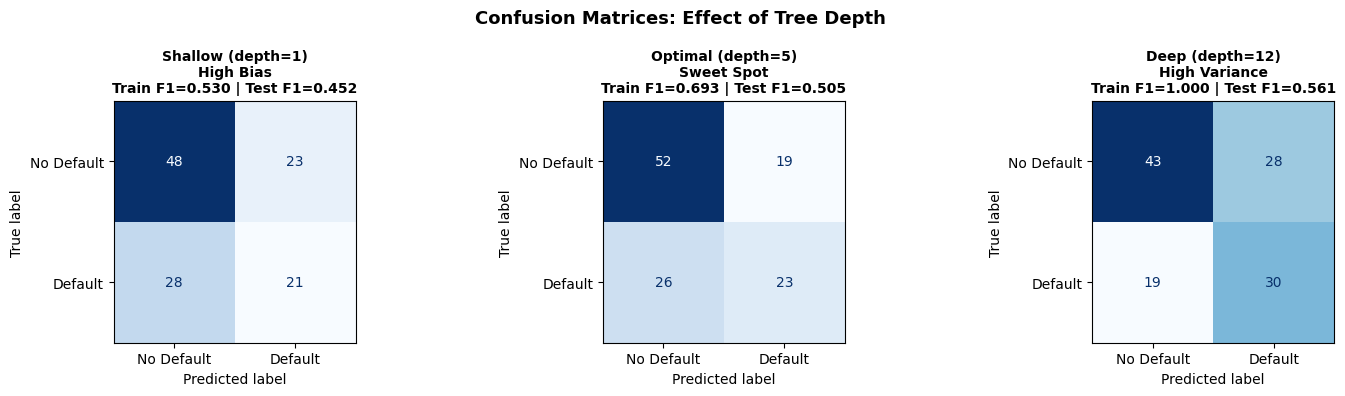

In [91]:
# --- Confusion Matrices: Shallow vs Optimal vs Deep tree ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

depths_to_compare = [1, best_depth, 12]
labels = ['Shallow (depth=1)\nHigh Bias', f'Optimal (depth={best_depth})\nSweet Spot', 'Deep (depth=12)\nHigh Variance']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, depth, label in zip(axes, depths_to_compare, labels):
    clf = Pipeline([
        ("preprocess", preprocess),
        ("clf", DecisionTreeClassifier(max_depth=depth, random_state=42)),
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    train_f1 = f1_score(y_train, clf.predict(X_train))
    test_f1  = f1_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{label}\nTrain F1={train_f1:.3f} | Test F1={test_f1:.3f}',
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices: Effect of Tree Depth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4) Learning Curve: Do We Need More Data?
Learning curves show how performance changes with training size.

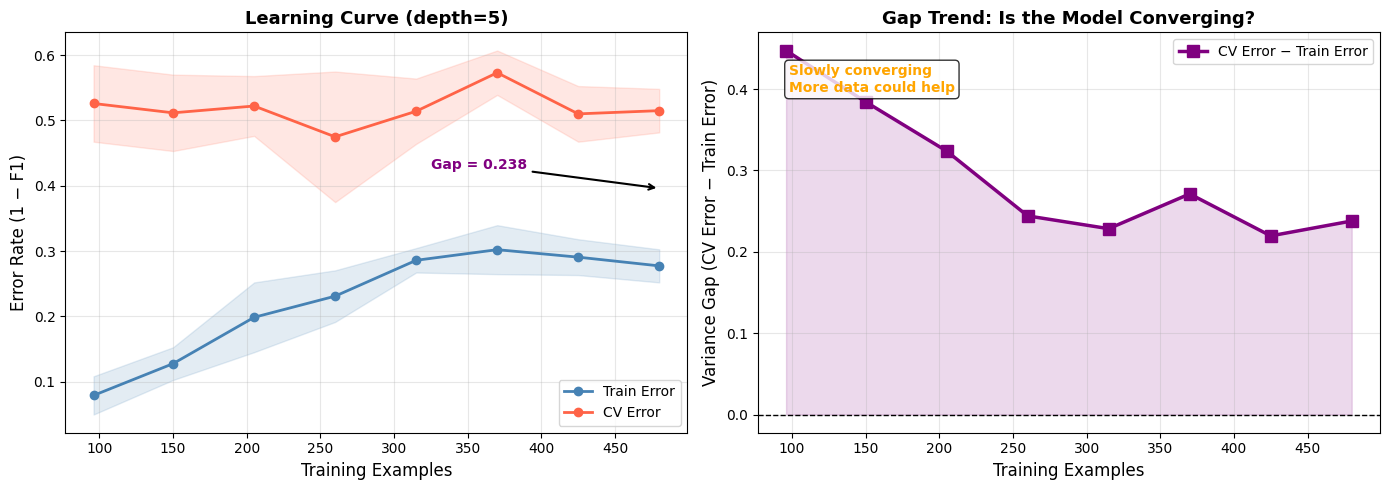

In [98]:
best_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=best_depth, random_state=42)),
])

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 8),
)

train_mean = 1 - train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = 1 - val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)
gap        = val_mean - train_mean    # CV error - train error

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Learning curves with fill ---
ax1.plot(train_sizes, train_mean, 'o-', lw=2, color='steelblue', label='Train Error')
ax1.plot(train_sizes, val_mean,   'o-', lw=2, color='tomato',    label='CV Error')
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
ax1.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color='tomato')

# Convergence annotation
final_gap = gap[-1]   # CV error - train error
ax1.annotate(f'Gap = {final_gap:.3f}',
             xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1]) / 2),
             xytext=(train_sizes[-2] - 100, (train_mean[-1] + val_mean[-1]) / 2 + 0.03),
             arrowprops=dict(arrowstyle='->', lw=1.5),
             fontsize=10, color='purple', fontweight='bold')

ax1.set_xlabel('Training Examples', fontsize=12)
ax1.set_ylabel('Error Rate (1 − F1)', fontsize=12)
ax1.set_title(f'Learning Curve (depth={best_depth})', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Right: Gap trend (converging or not?) ---
ax2.plot(train_sizes, gap, 's-', lw=2.5, color='purple', markersize=8, label='CV Error − Train Error')
ax2.axhline(0, color='black', linestyle='--', lw=1)
ax2.fill_between(train_sizes, 0, gap, alpha=0.15, color='purple')

# Convergence message
if gap[-1] < 0.05:
    msg = 'Converging  ✓\nMore data may not help much'
    col = 'green'
elif (gap[-1] - gap[0]) < 0:
    msg = 'Slowly converging\nMore data could help'
    col = 'orange'
else:
    msg = 'Not converging\nModel needs regularization'
    col = 'red'

ax2.text(0.05, 0.92, msg, transform=ax2.transAxes,
         fontsize=10, color=col, fontweight='bold', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.set_xlabel('Training Examples', fontsize=12)
ax2.set_ylabel('Variance Gap (CV Error − Train Error)', fontsize=12)
ax2.set_title('Gap Trend: Is the Model Converging?', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5) Quick Interpretation Checklist
- Train high, CV low → variance / overfitting
- Train low, CV low → bias / underfitting
- CV improves steadily with more data → more data likely helps

Next notebook: implement multiple classifiers and compare them fairly.

## 6) Feature Importance: What Does the Best Tree Use?

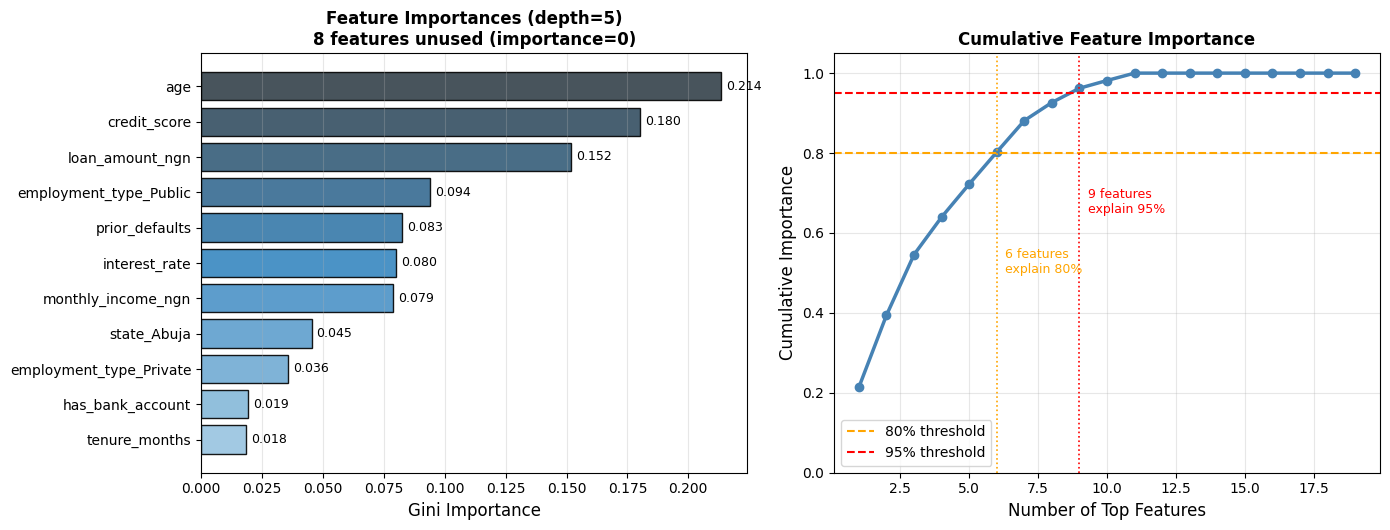


Final model performance on held-out test set (depth=5):
  F1  : 0.5055
  Acc : 0.6250


In [93]:
# Fit the best model on the full training split and extract feature importances
best_model.fit(X_train, y_train)

# Build feature name list (numeric + OHE categorical)
ohe_features = list(
    best_model.named_steps['preprocess']
    .named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(categorical_features)
)
all_feature_names = numeric_features + ohe_features

importances = best_model.named_steps['clf'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

# Split into zero and non-zero
nonzero = feat_imp_df[feat_imp_df['Importance'] > 0]
n_zero  = (feat_imp_df['Importance'] == 0).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(5, len(nonzero) * 0.4 + 1)))

# --- Left: Horizontal bar chart of non-zero importances ---
colors = sns.color_palette("Blues_d", len(nonzero))
ax1.barh(nonzero['Feature'], nonzero['Importance'], color=colors, edgecolor='black', alpha=0.9)
ax1.set_xlabel('Gini Importance', fontsize=12)
ax1.set_title(f'Feature Importances (depth={best_depth})\n{n_zero} features unused (importance=0)',
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
for i, (val, name) in enumerate(zip(nonzero['Importance'], nonzero['Feature'])):
    ax1.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

# --- Right: Cumulative importance ---
sorted_imp = feat_imp_df.sort_values('Importance', ascending=False)
cumulative  = sorted_imp['Importance'].cumsum().values
ax2.plot(range(1, len(cumulative)+1), cumulative, 'o-', lw=2.5, color='steelblue')
ax2.axhline(0.80, color='orange', linestyle='--', lw=1.5, label='80% threshold')
ax2.axhline(0.95, color='red',    linestyle='--', lw=1.5, label='95% threshold')
n80 = int(np.searchsorted(cumulative, 0.80)) + 1
n95 = int(np.searchsorted(cumulative, 0.95)) + 1
ax2.axvline(n80, color='orange', linestyle=':', lw=1.2)
ax2.axvline(n95, color='red',    linestyle=':', lw=1.2)
ax2.text(n80 + 0.3, 0.50, f'{n80} features\nexplain 80%', color='orange', fontsize=9)
ax2.text(n95 + 0.3, 0.65, f'{n95} features\nexplain 95%', color='red',    fontsize=9)
ax2.set_xlabel('Number of Top Features', fontsize=12)
ax2.set_ylabel('Cumulative Importance', fontsize=12)
ax2.set_title('Cumulative Feature Importance', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"\nFinal model performance on held-out test set (depth={best_depth}):")
print(f"  F1  : {f1_score(y_test, best_model.predict(X_test)):.4f}")
print(f"  Acc : {accuracy_score(y_test, best_model.predict(X_test)):.4f}")

## 7) Three Model Archetypes: Bias vs Variance vs Balanced

| Archetype | Setting | Symptom |
|---|---|---|
| **High Bias** | `max_depth=1` | Train F1 low **and** CV F1 low — both curves stuck near the floor |
| **High Variance** | `max_depth=15` | Train F1 ≈ 1.0, CV F1 much lower — huge gap that doesn't close |
| **Balanced** | `max_depth=best_depth` | Train and CV F1 converge — gap is small and closing |

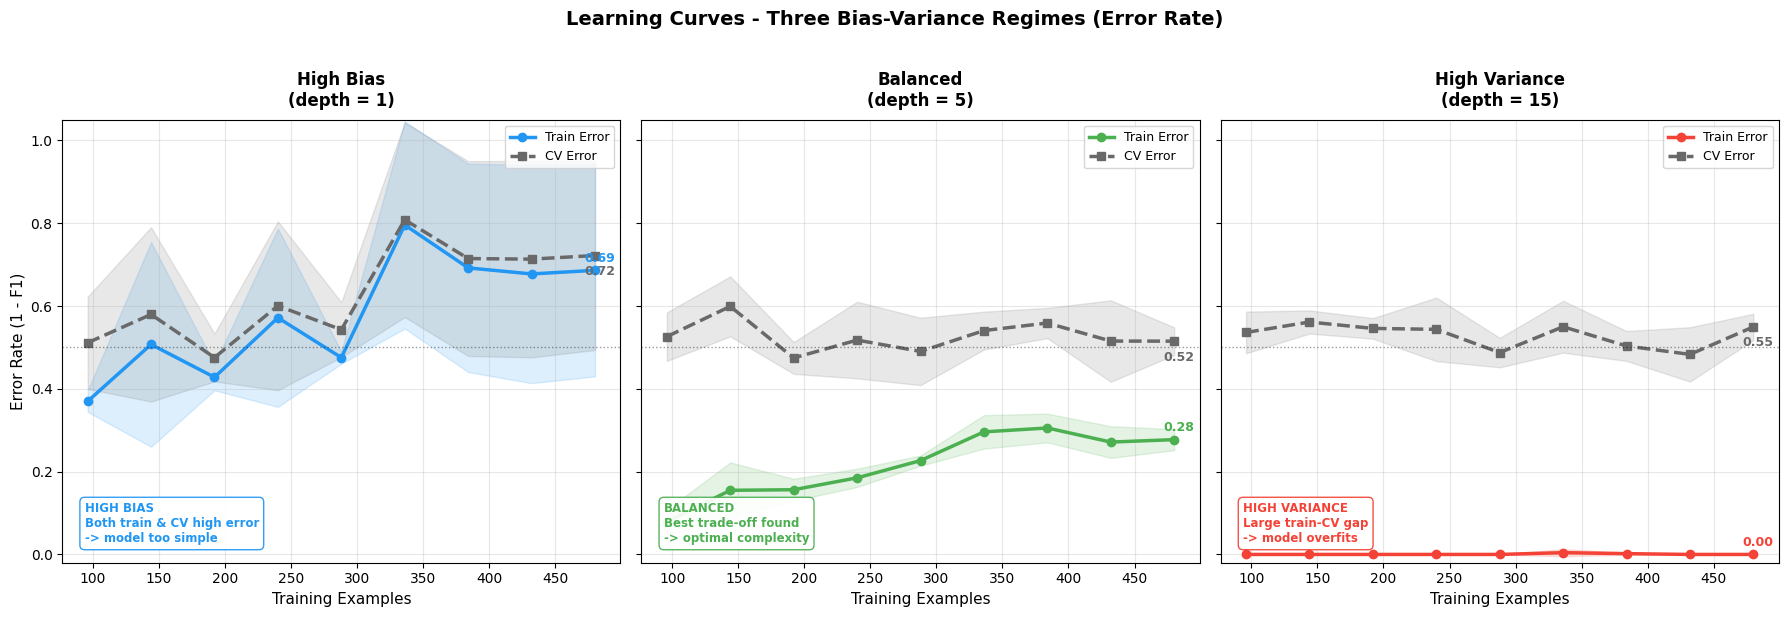


  DIAGNOSTIC SUMMARY  (lower error = better)
                     Model Train Error CV Error    Gap     Diagnosis
     High Bias (depth = 1)       0.686    0.722 +0.036     HIGH BIAS
      Balanced (depth = 5)       0.277    0.515 +0.238      BALANCED
High Variance (depth = 15)       0.000    0.550 +0.550 HIGH VARIANCE

Rule of thumb:
  * Both errors HIGH   -> increase model complexity (reduce bias)
  * Large CV-Train GAP -> regularise / get more data (reduce variance)
  * Errors CONVERGING  -> model is in the sweet spot


In [100]:
from sklearn.model_selection import learning_curve

# ── Define the three archetypes ───────────────────────────────────────────────
archetypes = {
    "High Bias\n(depth = 1)":            DecisionTreeClassifier(max_depth=1,         random_state=42),
    f"Balanced\n(depth = {best_depth})": DecisionTreeClassifier(max_depth=best_depth, random_state=42),
    "High Variance\n(depth = 15)":       DecisionTreeClassifier(max_depth=15,        random_state=42),
}
palette = {
    "High Bias\n(depth = 1)":            "#2196F3",
    f"Balanced\n(depth = {best_depth})": "#4CAF50",
    "High Variance\n(depth = 15)":       "#F44336",
}

# Thresholds for diagnosis (error-space)
BIAS_HIGH      = 1 - 0.60   # both curves above this  -> high bias  (error > 0.40)
VARIANCE_FLOOR = 0.40        # CV error - train error above this -> high variance

TRAIN_SIZES = np.linspace(0.20, 1.0, 9)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
summary_rows = []

for ax, (label, clf_obj) in zip(axes, archetypes.items()):
    pipe = Pipeline([("preprocess", preprocess), ("clf", clf_obj)])

    sizes, tr_scores, cv_scores = learning_curve(
        pipe, X, y,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        train_sizes=TRAIN_SIZES,
    )

    tr_err = 1 - tr_scores.mean(axis=1)
    tr_s   = tr_scores.std(axis=1)
    cv_err = 1 - cv_scores.mean(axis=1)
    cv_s   = cv_scores.std(axis=1)
    color  = palette[label]

    ax.plot(sizes, tr_err, "o-",  lw=2.5, color=color,    label="Train Error")
    ax.plot(sizes, cv_err, "s--", lw=2.5, color="dimgray", label="CV Error")
    ax.fill_between(sizes, tr_err - tr_s, tr_err + tr_s, alpha=0.15, color=color)
    ax.fill_between(sizes, cv_err - cv_s, cv_err + cv_s, alpha=0.15, color="dimgray")
    ax.axhline(0.5, ls=":", lw=1, color="black", alpha=0.4)

    ax.annotate(f"{tr_err[-1]:.2f}", (sizes[-1], tr_err[-1]),
                xytext=(-8, 6), textcoords="offset points",
                fontsize=9, color=color, fontweight="bold")
    ax.annotate(f"{cv_err[-1]:.2f}", (sizes[-1], cv_err[-1]),
                xytext=(-8, -14), textcoords="offset points",
                fontsize=9, color="dimgray", fontweight="bold")

    gap = cv_err[-1] - tr_err[-1]   # CV error - train error (positive when overfitting)
    both_high = tr_err[-1] > BIAS_HIGH and cv_err[-1] > BIAS_HIGH

    if both_high:
        badge = "HIGH BIAS\nBoth train & CV high error\n-> model too simple"
        badge_color = "#2196F3"
    elif gap > VARIANCE_FLOOR:
        badge = "HIGH VARIANCE\nLarge train-CV gap\n-> model overfits"
        badge_color = "#F44336"
    else:
        badge = "BALANCED\nBest trade-off found\n-> optimal complexity"
        badge_color = "#4CAF50"

    ax.text(0.04, 0.04, badge, transform=ax.transAxes, fontsize=8.5,
            color=badge_color, fontweight="bold", va="bottom",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor=badge_color, alpha=0.92))

    ax.set_title(label, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Training Examples", fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel("Error Rate (1 - F1)", fontsize=11)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.02, 1.05)

    summary_rows.append({
        "Model":       label.replace("\n", " "),
        "Train Error": f"{tr_err[-1]:.3f}",
        "CV Error":    f"{cv_err[-1]:.3f}",
        "Gap":         f"{gap:+.3f}",
        "Diagnosis":   badge.split("\n")[0],
    })

plt.suptitle("Learning Curves - Three Bias-Variance Regimes (Error Rate)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 72)
print("  DIAGNOSTIC SUMMARY  (lower error = better)")
print("=" * 72)
df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))
print("=" * 72)
print("\nRule of thumb:")
print("  * Both errors HIGH   -> increase model complexity (reduce bias)")
print("  * Large CV-Train GAP -> regularise / get more data (reduce variance)")
print("  * Errors CONVERGING  -> model is in the sweet spot")


## 8) Test-Set Evaluation: How Each Archetype Generalises

Each model is trained on the full training split and evaluated on the **held-out test set**.
- **Confusion matrix** — where predictions go right/wrong  
- **Predicted probability histogram** — how confident/spread each model is  
- **ROC curve + metrics bar** — overall discriminative ability

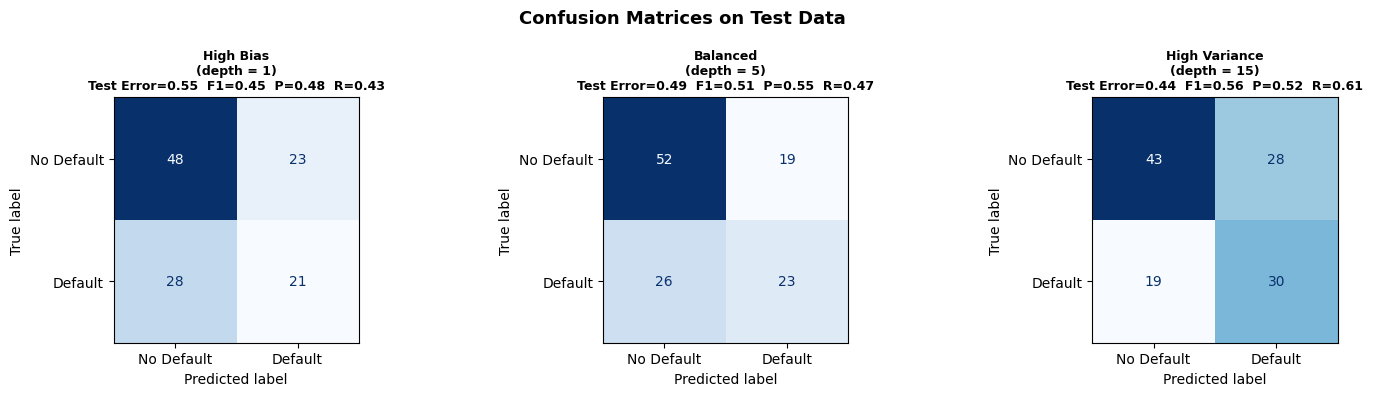

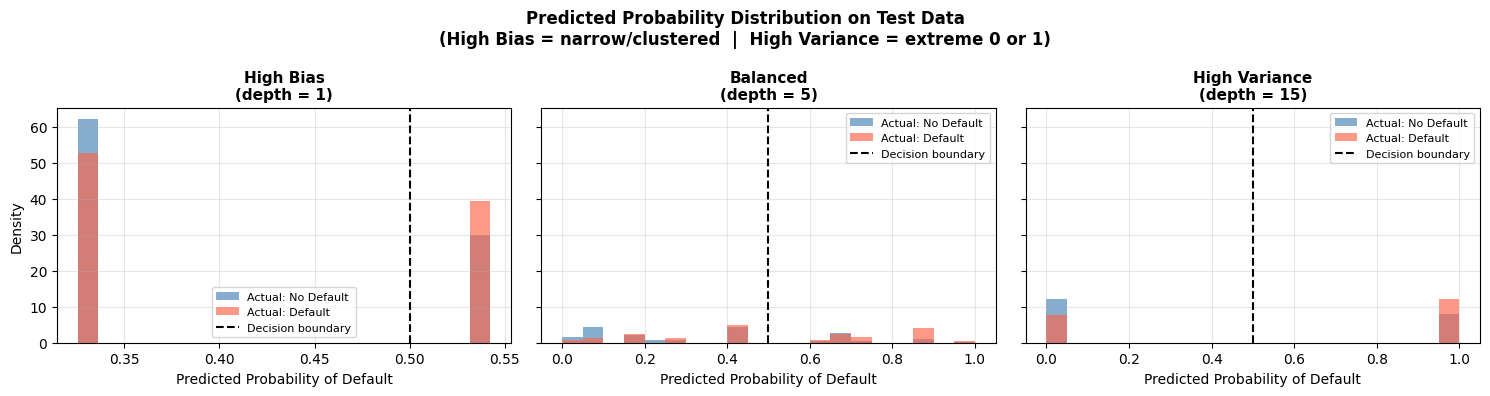

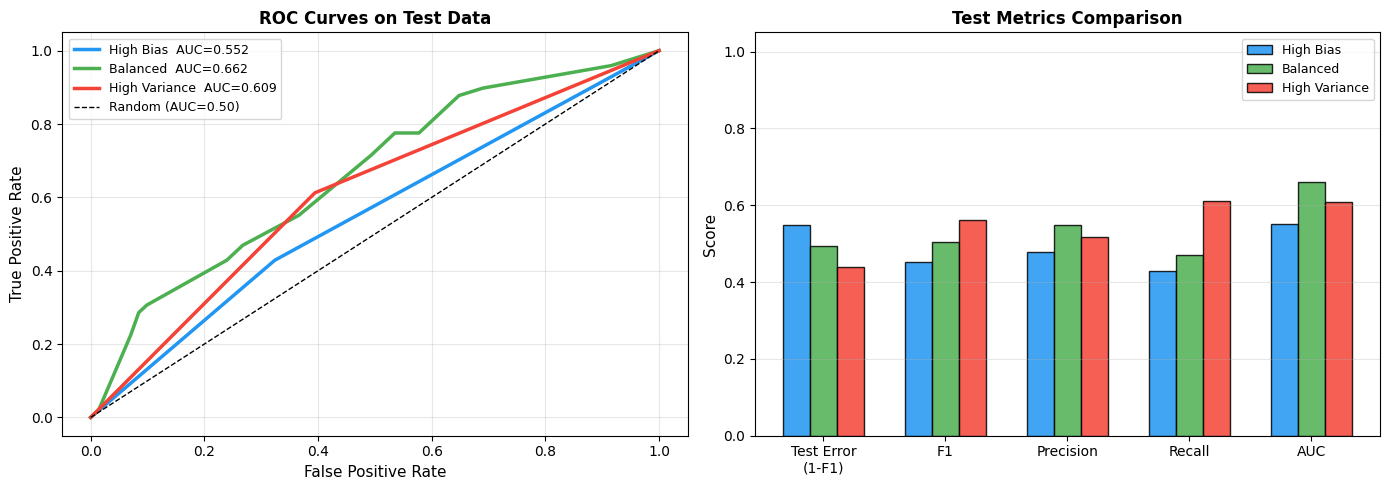


  TEST-SET METRICS SUMMARY
        Model Error    F1 Precision Recall   AUC
    High Bias 0.548 0.452     0.477  0.429 0.552
     Balanced 0.495 0.505     0.548  0.469 0.662
High Variance 0.439 0.561     0.517  0.612 0.609


In [101]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

# ── Archetypes (same depths as learning-curve section) ───────────────────────
test_archetypes = {
    "High Bias\n(depth = 1)":            (DecisionTreeClassifier(max_depth=1,         random_state=42), "#2196F3"),
    f"Balanced\n(depth = {best_depth})": (DecisionTreeClassifier(max_depth=best_depth, random_state=42), "#4CAF50"),
    "High Variance\n(depth = 15)":       (DecisionTreeClassifier(max_depth=15,        random_state=42), "#F44336"),
}

# ── Fit on X_train, evaluate on X_test ───────────────────────────────────────
fitted = {}
for label, (clf_obj, color) in test_archetypes.items():
    pipe = Pipeline([("preprocess", preprocess), ("clf", clf_obj)])
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fitted[label] = dict(pipe=pipe, pred=y_pred, proba=y_proba, color=color)

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 1 — Confusion Matrices
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, d) in zip(axes1, fitted.items()):
    cm = confusion_matrix(y_test, d["pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")

    err  = 1 - f1_score(y_test, d["pred"])
    prec = precision_score(y_test, d["pred"], zero_division=0)
    rec  = recall_score(y_test, d["pred"], zero_division=0)
    f1   = f1_score(y_test, d["pred"], zero_division=0)

    ax.set_title(
        f"{label}\nTest Error={err:.2f}  F1={f1:.2f}  P={prec:.2f}  R={rec:.2f}",
        fontsize=9, fontweight="bold",
    )

fig1.suptitle("Confusion Matrices on Test Data", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 2 — Predicted Probability Histograms
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (label, d) in zip(axes2, fitted.items()):
    color = d["color"]
    probas = d["proba"]

    ax.hist(probas[y_test == 0], bins=20, alpha=0.65, color="steelblue",
            label="Actual: No Default", density=True)
    ax.hist(probas[y_test == 1], bins=20, alpha=0.65, color="tomato",
            label="Actual: Default", density=True)

    ax.axvline(0.5, ls="--", lw=1.5, color="black", label="Decision boundary")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted Probability of Default", fontsize=10)
    if ax == axes2[0]:
        ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig2.suptitle("Predicted Probability Distribution on Test Data\n"
              "(High Bias = narrow/clustered  |  High Variance = extreme 0 or 1)",
              fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 3 — ROC Curves (overlay) + Metrics Bar Chart
# ═══════════════════════════════════════════════════════════════════════════════
fig3, (ax_roc, ax_bar) = plt.subplots(1, 2, figsize=(14, 5))

metric_names = ["Test Error\n(1-F1)", "F1", "Precision", "Recall", "AUC"]
x_pos = np.arange(len(metric_names))
bar_width = 0.22
metric_rows = []

for i, (label, d) in enumerate(fitted.items()):
    fpr, tpr, _ = roc_curve(y_test, d["proba"])
    auc = roc_auc_score(y_test, d["proba"])
    f1  = f1_score(y_test, d["pred"], zero_division=0)
    prec = precision_score(y_test, d["pred"], zero_division=0)
    rec  = recall_score(y_test, d["pred"], zero_division=0)
    err  = 1 - f1

    short = label.split("\n")[0]
    ax_roc.plot(fpr, tpr, lw=2.5, color=d["color"], label=f"{short}  AUC={auc:.3f}")

    values = [err, f1, prec, rec, auc]
    ax_bar.bar(x_pos + i * bar_width, values, bar_width,
               label=short, color=d["color"], alpha=0.85, edgecolor="black")

    metric_rows.append({"Model": short, "Error": f"{err:.3f}", "F1": f"{f1:.3f}",
                         "Precision": f"{prec:.3f}", "Recall": f"{rec:.3f}", "AUC": f"{auc:.3f}"})

# ROC diagonal
ax_roc.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.50)")
ax_roc.set_xlabel("False Positive Rate", fontsize=11)
ax_roc.set_ylabel("True Positive Rate", fontsize=11)
ax_roc.set_title("ROC Curves on Test Data", fontsize=12, fontweight="bold")
ax_roc.legend(fontsize=9)
ax_roc.grid(True, alpha=0.3)

ax_bar.set_xticks(x_pos + bar_width)
ax_bar.set_xticklabels(metric_names, fontsize=10)
ax_bar.set_ylabel("Score", fontsize=11)
ax_bar.set_title("Test Metrics Comparison", fontsize=12, fontweight="bold")
ax_bar.legend(fontsize=9)
ax_bar.set_ylim(0, 1.05)
ax_bar.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  TEST-SET METRICS SUMMARY")
print("=" * 65)
print(pd.DataFrame(metric_rows).to_string(index=False))
print("=" * 65)
